In [1]:
import figure_settings
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from figure_settings import style_settings

from conus_biomass import dir_info
from conus_biomass.make_figures import maps

# Load data

In [2]:
# Load saved figure data
save_dir = "figure_data/figure_1/"

df_fire = pd.read_csv(save_dir + "fire_timeseries.csv")
burned_forest_tseries = xr.DataArray(
    df_fire["burned_forest"].values, coords={"year": df_fire["year"].values}, dims=["year"]
)
forest_area = xr.DataArray(
    df_fire["forest_area"].values, coords={"year": df_fire["year"].values}, dims=["year"]
)

df_fia = pd.read_csv(save_dir + "fia_timeseries.csv")
fia_frac_plots = xr.DataArray(
    df_fia["fia_frac_plots"].values, coords={"year": df_fia["year"].values}, dims=["year"]
)

with open(save_dir + "target_crs.txt") as f:
    crs = f.read()

mapdata_clipped = xr.open_dataset(save_dir + "mapdata_clipped.nc")["mapdata_clipped"].rio.write_crs(
    crs
)
is_forest_clipped = xr.open_dataset(save_dir + "is_forest_clipped.nc")[
    "is_forest_clipped"
].rio.write_crs(crs)

western_states = maps.SHP_WESTERN.to_crs(crs)

# Recreate colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap", [figure_settings.color_MTBS_light, figure_settings.color_MTBS]
)
n_colors = 5
discrete_cmap = mcolors.ListedColormap(cmap(np.linspace(0, 1, n_colors)))

# Make figure

/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


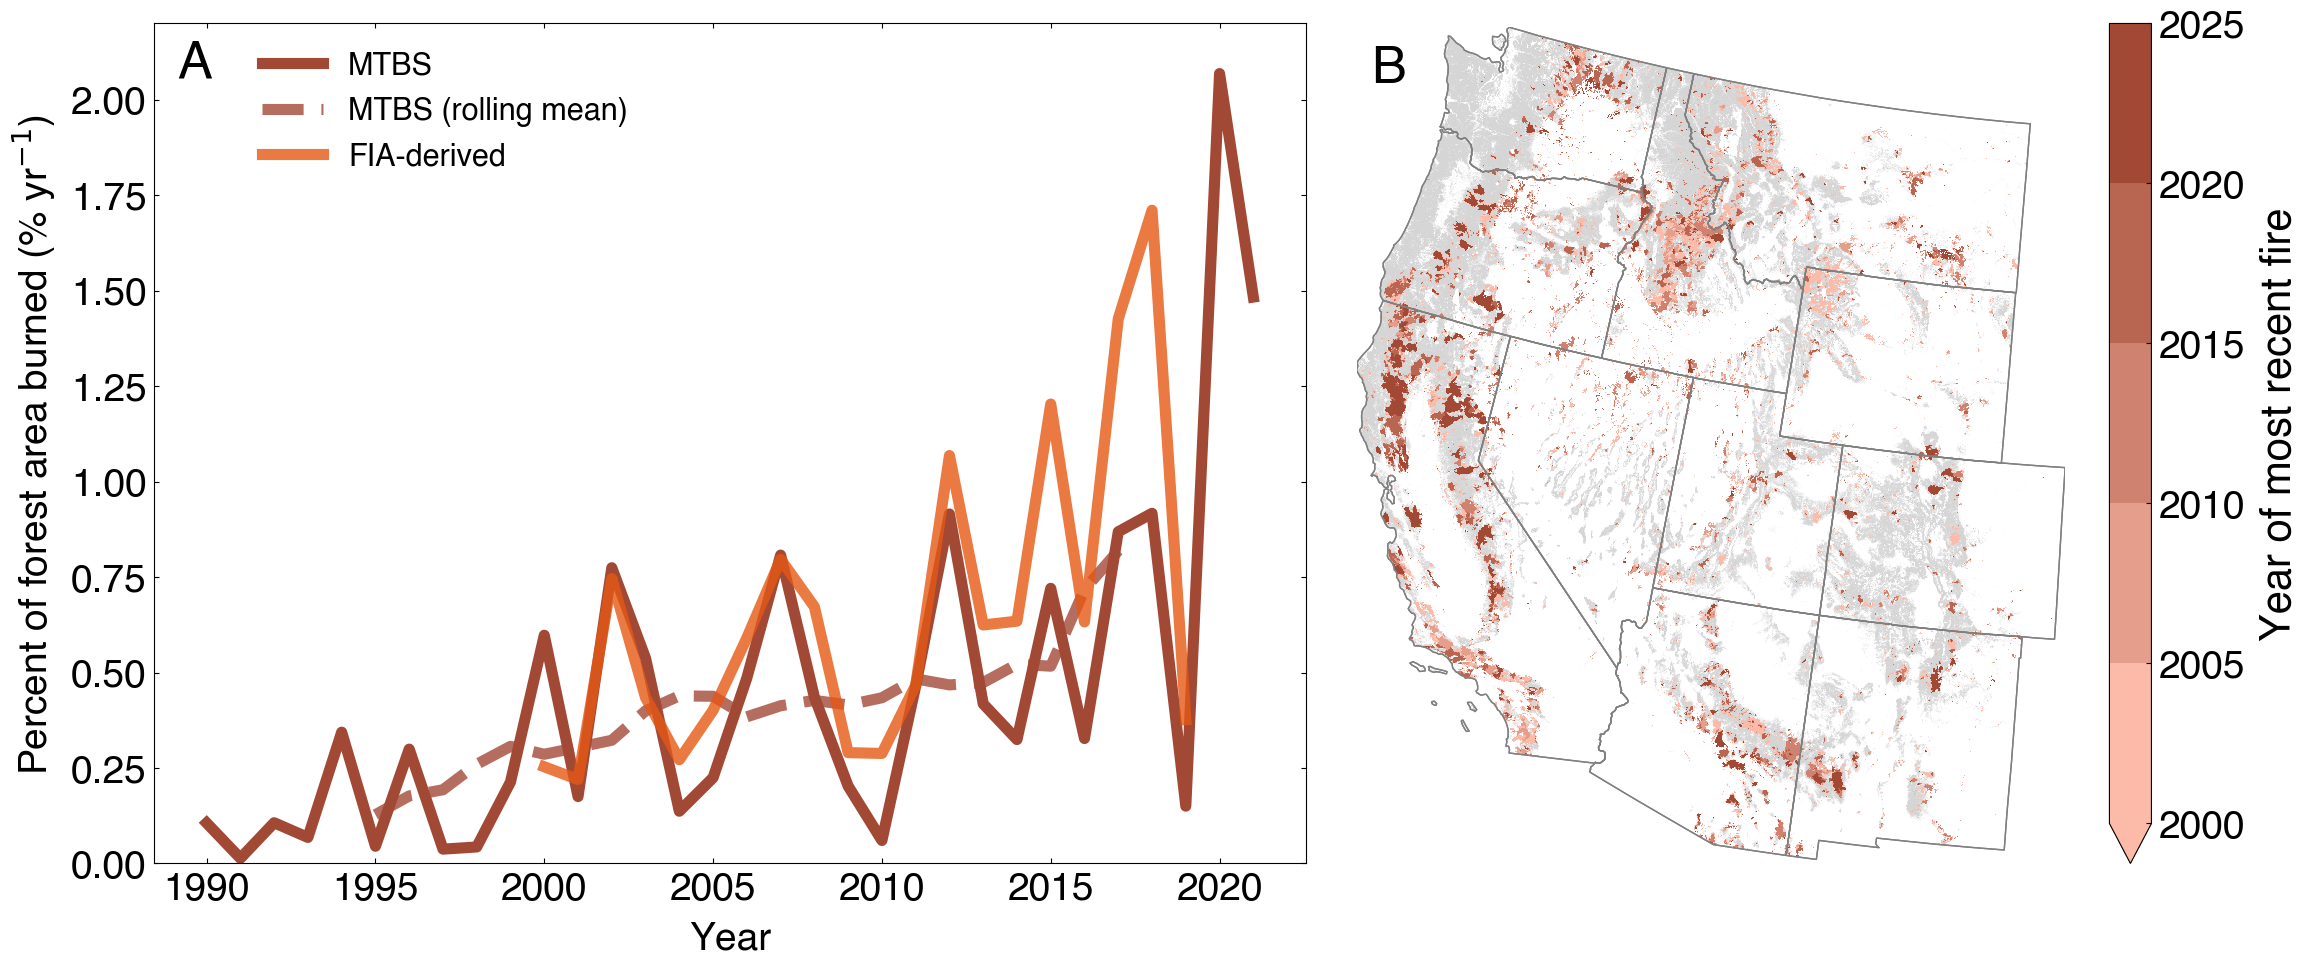

In [3]:
fig = plt.figure(figsize=(24, 10))

figure_settings.apply_style()

# Create axes with width ratios: left panel smaller, right panel bigger
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.05)
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

##############################################################################################################
##############################################################################################################

ax0 = axes[0]
yvals = burned_forest_tseries * 100 / forest_area
ax0.plot(yvals["year"], yvals, "-", color=figure_settings.color_MTBS, markersize=15, label="MTBS")
ax0.plot(
    yvals["year"],
    yvals.rolling(year=10, center=True).mean(),
    "--",
    color=figure_settings.color_MTBS,
    label="MTBS (rolling mean)",
    alpha=0.8,
)
ax0.plot(
    fia_frac_plots["year"],
    fia_frac_plots.where(fia_frac_plots["year"] >= 2000),
    color=figure_settings.color_FIA_fire,
    label="FIA-derived",
    alpha=0.8,
)
ax0.set_ylim([0, 2.2])
ax0.set_ylabel("Percent of forest area burned (% yr$^{-1}$)", labelpad=10)
ax0.set_xlabel("Year", labelpad=10)
# ax0.set_title("Forest area burned annually", pad=15)
ax0.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.07, 1))

##############################################################################################################
##############################################################################################################

ax1 = axes[1]
maps.plot_map(
    is_forest_clipped,
    shp=western_states,
    latlon=False,
    cbar_label="Percent Forest",
    cmap=plt.cm.binary,
    add_colorbar=False,
    clims=[0, 600],
    savefig=None,
    ax=ax1,
)
maps.plot_map(
    mapdata_clipped,
    shp=western_states,
    latlon=False,
    title="",  # Year of most recent fire",
    cbar_label="Year of most recent fire",
    cmap=discrete_cmap,
    savefig=None,
    clims=[2000, 2025],
    add_colorbar=True,
    ax=ax1,
)
# ax1.set_title("Year of most recent fire", pad=15)

# The colorbar is on a separate axes appended to the figure
for ax in fig.axes:
    if ax != ax0 and ax != ax1:  # it's the colorbar axes
        ax.yaxis.label.set_fontsize(style_settings["axes.titlesize"])
        ax.tick_params(labelsize=style_settings["xtick.labelsize"])
        ax.set_ylabel("Year of most recent fire", labelpad=10)

##############################################################################################################
##############################################################################################################

panel_labels = ["A", "B"]
for i, ax in enumerate(axes):
    ax.text(
        0.02,
        0.98,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=style_settings["axes.titlesize"] * 1.25,
        fontweight="bold",
        va="top",
    )
    # ax.spines[["right", "top"]].set_visible(True)
    # ax.tick_params(axis="y", which="both", left=True, right=True, direction="in")
    # ax.tick_params(axis="x", which="both", top=True, bottom=True, direction="in")

axes[1].set(rasterized=True)

fig.subplots_adjust(left=0.05, right=0.92, top=0.92, bottom=0.08, wspace=-0.1)
# fig.savefig(dir_info.dir_figures + "Figure1.jpg", bbox_inches="tight", dpi=300)
fig.savefig(dir_info.dir_figures + "fig-fire_motivation_figure.jpg", bbox_inches="tight", dpi=300)
fig.savefig(dir_info.dir_figures + "fig-fire_motivation_figure.pdf", bbox_inches="tight")

/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/clairezarakas/Documents/science/conus-biomass/src/conus_biomass/make_figures/maps.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


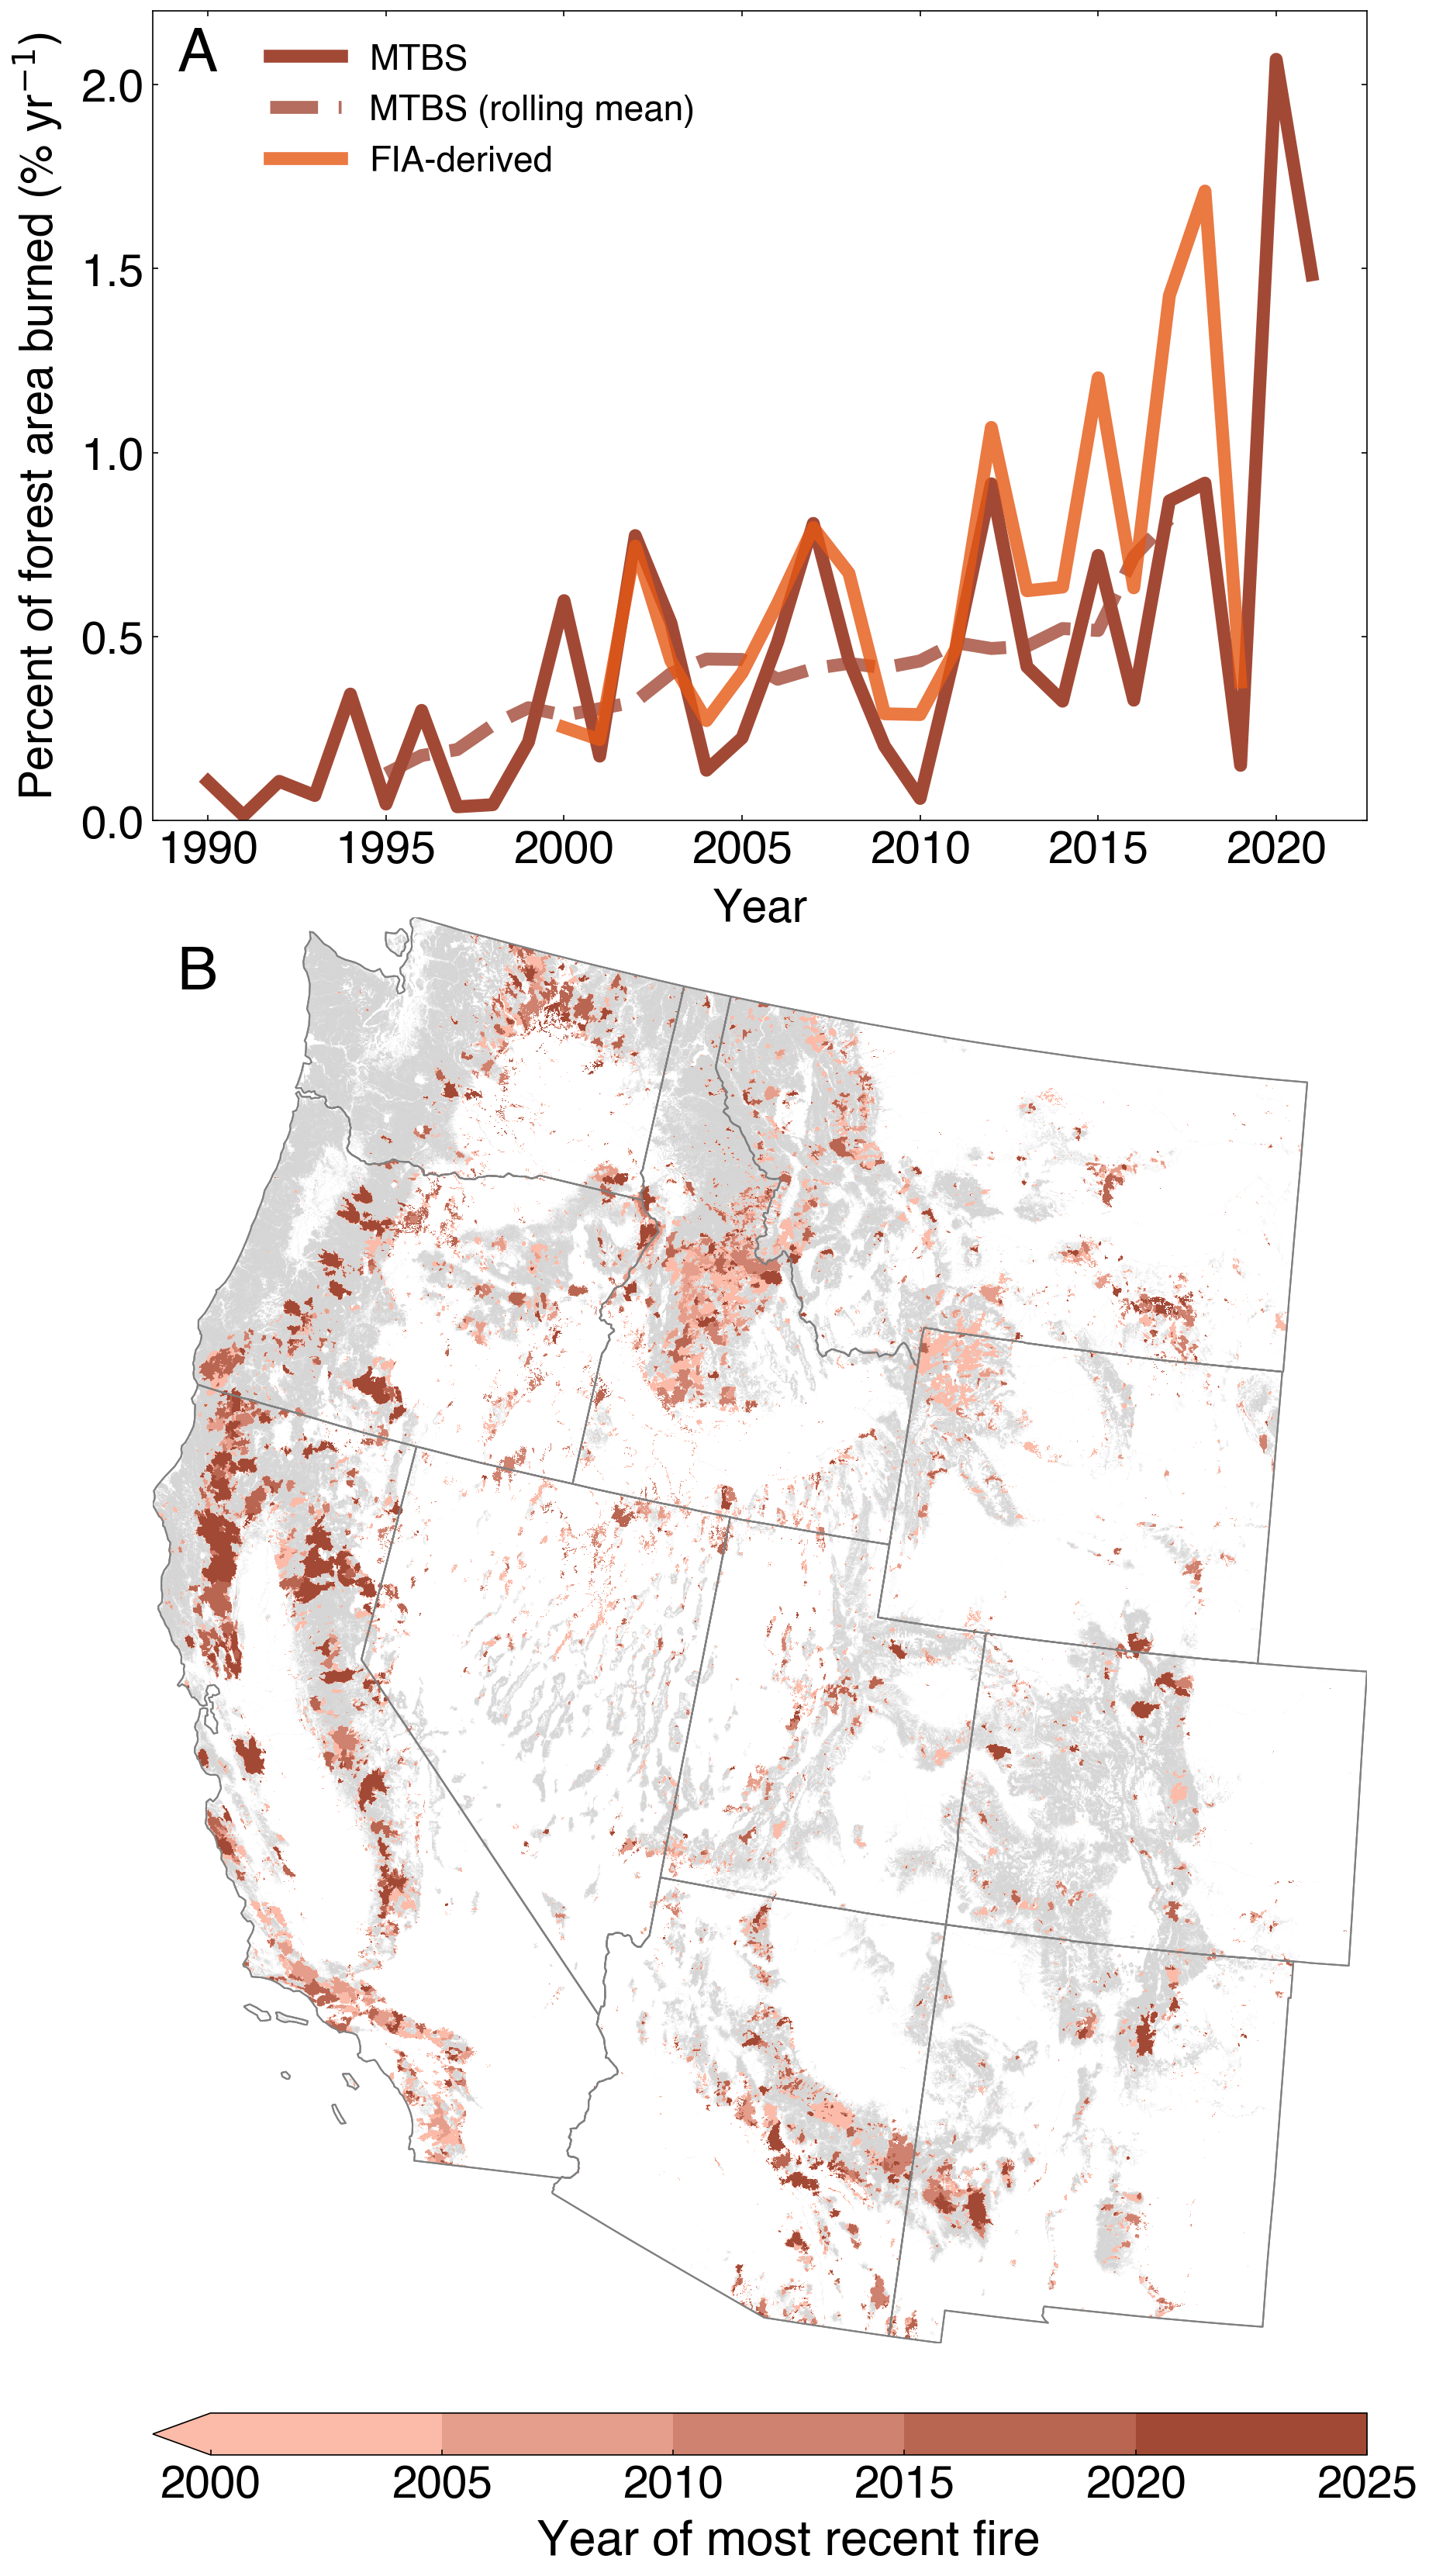

In [4]:
fig = plt.figure(figsize=(12, 24))

figure_settings.apply_style()

# Create axes with height ratios: left panel smaller, right panel bigger
gs = fig.add_gridspec(2, 1, height_ratios=[1, 2], wspace=0.01)
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

##############################################################################################################
##############################################################################################################

ax0 = axes[0]
yvals = burned_forest_tseries * 100 / forest_area
ax0.plot(yvals["year"], yvals, "-", color=figure_settings.color_MTBS, markersize=15, label="MTBS")
ax0.plot(
    yvals["year"],
    yvals.rolling(year=10, center=True).mean(),
    "--",
    color=figure_settings.color_MTBS,
    label="MTBS (rolling mean)",
    alpha=0.8,
)
ax0.plot(
    fia_frac_plots["year"],
    fia_frac_plots.where(fia_frac_plots["year"] >= 2000),
    color=figure_settings.color_FIA_fire,
    label="FIA-derived",
    alpha=0.8,
)
ax0.set_ylim([0, 2.2])
ax0.set_ylabel("Percent of forest area burned (% yr$^{-1}$)", labelpad=10)
ax0.set_xlabel("Year", labelpad=10)
# ax0.set_title("Forest area burned annually", pad=15)
ax0.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.07, 1))

##############################################################################################################
##############################################################################################################

ax1 = axes[1]
maps.plot_map(
    is_forest_clipped,
    shp=western_states,
    latlon=False,
    cbar_label="Percent Forest",
    cmap=plt.cm.binary,
    add_colorbar=False,
    clims=[0, 600],
    savefig=None,
    ax=ax1,
)
maps.plot_map(
    mapdata_clipped,
    shp=western_states,
    latlon=False,
    title="",  # Year of most recent fire",
    cbar_label="Year of most recent fire",
    cmap=discrete_cmap,
    savefig=None,
    clims=[2000, 2025],
    add_colorbar=False,  # Disabled; added manually as horizontal below
    ax=ax1,
)

##############################################################################################################
##############################################################################################################

panel_labels = ["A", "B"]
for i, ax in enumerate(axes):
    ax.text(
        0.02,
        0.98,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=style_settings["axes.titlesize"] * 1.25,
        fontweight="bold",
        va="top",
    )

axes[1].set(rasterized=True)

fig.subplots_adjust(left=0.05, right=0.92, top=0.95, bottom=0.08, hspace=0)

# Draw to finalise positions, then add horizontal colorbar below map
fig.canvas.draw()
ax1_pos = ax1.get_position()
cax = fig.add_axes([ax1_pos.x0, ax1_pos.y0 - 0.04, ax1_pos.width, 0.015])
sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=plt.Normalize(vmin=2000, vmax=2025))
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", extend="min")
cbar.set_label("Year of most recent fire", labelpad=8, fontsize=style_settings["axes.titlesize"])
cbar.ax.tick_params(labelsize=style_settings["xtick.labelsize"])

# fig.savefig(dir_info.dir_figures + "Figure1.jpg", bbox_inches="tight", dpi=300)
fig.savefig(
    dir_info.dir_figures + "fig-fire_motivation_figure_stacked.jpg", bbox_inches="tight", dpi=300
)
fig.savefig(dir_info.dir_figures + "fig-fire_motivation_figure_stacked.pdf", bbox_inches="tight")